In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [15]:
complications = ['HYPEV','CHLEV','HRTEV', 'AASMEV','ARTH1']

### Create a function to seperate indivisuals with diabetes
- (1) Yes
- (2) No
- (3) Borderline or Prediabetes: which we will treat as diabetic cases

In [17]:
def diabetes_status(df, diabetes_column='DIBEV1'):
    # Filter for 'No Diabetes' (DIBEV1 = 2)
    no_diabetes = df[df[diabetes_column] == 2]
    
    # Filter for 'Diabetes' (DIBEV1 = 1 or 3)
    diabetes = df[df[diabetes_column].isin([1, 3])]
    
    return diabetes, no_diabetes

### Create a function for permutation testing

In [18]:
def permutation_test(diabetes_group, non_diabetes_group, complications, n_permutations=10000):
    """
    Performs a permutation test for each complication between diabetes and non-diabetes groups.

    Parameters:
    - diabetes_group (DataFrame): DataFrame containing only the diabetes group.
    - non_diabetes_group (DataFrame): DataFrame containing only the non-diabetes group.
    - complications (list): List of complications to test.
    - n_permutations (int): Number of permutations to perform.

    Returns:
    - DataFrame: Contains each complication, observed difference, and p-value.
    """
    # Define sample sizes for diabetes and non-diabetes groups
    n_diabetes = len(diabetes_group)
    n_no_diabetes = len(non_diabetes_group)
    
    # Initialize a dictionary to store permutation test results
    permutation_results = {
        "Complication": [],
        "Observed Difference": [],
        "p-value": []
    }
    
    # Perform permutation test for each complication
    for complication in complications:
        # Calculate the observed difference in proportions
        observed_diff = diabetes_group[complication].mean() - non_diabetes_group[complication].mean()
        
        # Concatenate the complication data from both groups for shuffling
        combined = np.concatenate([diabetes_group[complication], non_diabetes_group[complication]])
        
        # Initialize a list to store permuted differences
        permuted_diffs = []
        
        # Permutation loop
        for _ in range(n_permutations):
            np.random.shuffle(combined)
            permuted_diabetes = combined[:n_diabetes]
            permuted_no_diabetes = combined[n_diabetes:]
            permuted_diff = permuted_diabetes.mean() - permuted_no_diabetes.mean()
            permuted_diffs.append(permuted_diff)
        
        # Calculate the p-value as the proportion of permuted diffs greater than or equal to the observed difference
        p_value = np.mean(np.abs(permuted_diffs) >= np.abs(observed_diff))
        
        # Store results
        permutation_results["Complication"].append(complication)
        permutation_results["Observed Difference"].append(observed_diff)
        permutation_results["p-value"].append(p_value)
    
    # Convert the results to a DataFrame for viewing
    return pd.DataFrame(permutation_results)


## Group 1 Testing

In [19]:
group1 = pd.read_csv('group1.csv')
group1.shape

(7025, 806)

In [20]:
group1_diabetes, group1_no = diabetes_status(group1)
print("group1_diabetes shape", group1_diabetes.shape)
print("group1_no shape", group1_no.shape)

group1_diabetes shape (283, 806)
group1_no shape (6742, 806)


#### Define function to calculate proportion

In [21]:
def complication_proportion(df, complication):
    proportion_with_complication = (df[complication] > 0).mean()
    return proportion_with_complication

In [22]:
# Initialize a dictionary to store results
complication_results = {
    "Complication": [],
    "Diabetes Proportion": [],
    "No Diabetes Proportion": []
}

# Loop through each complication to calculate proportions for both groups
for complication in complications:
    # Calculate the proportion for the diabetes group
    diabetes_prop = (group1_diabetes[complication] > 0).mean()
    # Calculate the proportion for the non-diabetes group
    no_diabetes_prop = (group1_no[complication] > 0).mean()
    
    # Append the results to the dictionary
    complication_results["Complication"].append(complication)
    complication_results["Diabetes Proportion"].append(diabetes_prop)
    complication_results["No Diabetes Proportion"].append(no_diabetes_prop)

# Convert the results dictionary to a DataFrame for easier viewing
group1_comparion = pd.DataFrame(complication_results)
group1_comparion


,Complication,Diabetes Proportion,No Diabetes Proportion
0,HYPEV,0.434629,0.115099
1,CHLEV,0.416961,0.099822
2,HRTEV,0.077739,0.029961
3,AASMEV,0.275618,0.129338
4,ARTH1,0.190813,0.073717


While this data appears promising at first glance, we still need to conduct a test to determine whether this hypothesis is valid. However, before proceeding, I believe it would be beneficial to reduce our restrictions in order to increase the sample size for the 'has diabetes' group.

### Group 1 bar graph, showing proportion of complcations for diabetes and non-diabetic subgroups

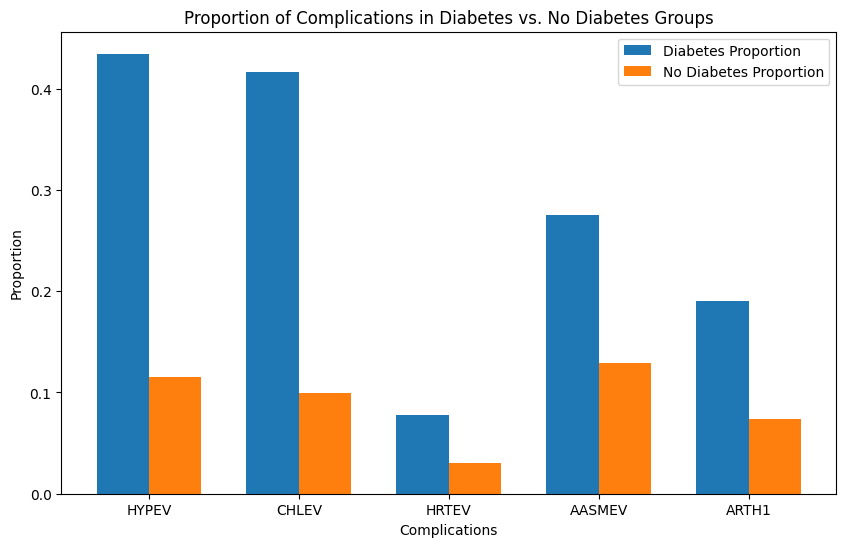

In [24]:
diabetes1 = [0.434629, 0.416961, 0.077739, 0.275618, 0.190813]
no_diabetes1 = [0.115099, 0.099822, 0.029961, 0.129338, 0.073717]

# Set up bar width and positions for side-by-side bars
bar_width = 0.35
index = np.arange(len(complications))

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Bars for diabetes group
diabetes_bars = ax.bar(index, diabetes1, bar_width, label="Diabetes Proportion")

# Bars for no diabetes group
no_diabetes_bars = ax.bar(index + bar_width, no_diabetes1, bar_width, label="No Diabetes Proportion")

# Adding labels and title
ax.set_xlabel("Complications")
ax.set_ylabel("Proportion")
ax.set_title("Proportion of Complications in Diabetes vs. No Diabetes Groups")
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(complications)
ax.legend()

# Display the plot
plt.show()

#### Chi Square Test

In [25]:
# Sample size for each group
total_diabetes = 6742
total_no_diabetes = 283

# Initialize dictionary to store results
statistical_results = {"Complication": [], "Chi-Square": [], "p-value": [], "Significant": []}

# Perform Chi-Square test for each complication
for i, complication in enumerate(complications):
    # Observed counts based on proportions and total sample sizes
    diabetes_with = int(diabetes1[i] * total_diabetes)
    diabetes_without = total_diabetes - diabetes_with
    no_diabetes_with = int(no_diabetes1[i] * total_no_diabetes)
    no_diabetes_without = total_no_diabetes - no_diabetes_with

    # Create contingency table
    contingency_table = [
        [diabetes_with, diabetes_without],
        [no_diabetes_with, no_diabetes_without]
    ]
    
    # Perform chi-square test
    chi2, p, _, _ = chi2_contingency(contingency_table)
    
    # Check if the result is significant at alpha = 0.05
    is_significant = p < 0.05
    
    # Append results
    statistical_results["Complication"].append(complication)
    statistical_results["Chi-Square"].append(chi2)
    statistical_results["p-value"].append(p)
    statistical_results["Significant"].append(is_significant)

# Display the results in a DataFrame
statistical_results_df = pd.DataFrame(statistical_results)
statistical_results_df

,Complication,Chi-Square,p-value,Significant
0,HYPEV,113.816242,1.429617e-26,True
1,CHLEV,112.736481,2.464460e-26,True
2,HRTEV,8.796336,3.018361e-03,True
3,AASMEV,29.616305,5.266011e-08,True
4,ARTH1,25.085932,5.483144e-07,True


### Permutation test 

In [26]:
permutation_results1 = permutation_test(group1_diabetes, group1_no, complications)
permutation_results1

,Complication,Observed Difference,p-value
0,HYPEV,0.319530,0.0000
1,CHLEV,0.317139,0.0000
2,HRTEV,0.047777,0.0004
3,AASMEV,0.146280,0.0000
4,ARTH1,0.117096,0.0000


#### We are obtaining very drastic p-values, so we will now use stability checks to see if this is consistent across all groupings

### Group 2

In [7]:
group2 = pd.read_csv('group2_female.csv')
group2_diabetes, group2_no = diabetes_status(group2)

print("group2 shape", group2.shape)
print("group2_diabetes shape", group2_diabetes.shape)
print("group2_no shape", group2_no.shape)

NameError: name 'diabetes_status' is not defined

In [8]:
permutation_results2 = permutation_test(group2_diabetes, group2_no, complications)
permutation_results2

NameError: name 'permutation_test' is not defined

### Group 3

In [9]:
group3 = pd.read_csv('group3.csv')
group3_diabetes, group3_no = diabetes_status(group3)

print("group3 shape:", group3.shape)
print("group3_diabetes shape:", group3_diabetes.shape)
print("group3_no shape:", group3_no.shape)

NameError: name 'diabetes_status' is not defined

In [ ]:
permutation_results3 = permutation_test(group3_diabetes, group3_no, complications)
permutation_results3

### Group 4

In [10]:
group4 = pd.read_csv('group4.csv')
group4_diabetes, group4_no = diabetes_status(group4)

print("group4 shape", group4.shape)
print("group4_diabetes shape:", group4_diabetes.shape)
print("group4_no shape:", group4_no.shape)

permutation_results4 = permutation_test(group4_diabetes, group4_no, complications)
permutation_results4

NameError: name 'diabetes_status' is not defined

### Group 5

In [11]:
group5 = pd.read_csv('group5.csv')
group5_diabetes, group5_no = diabetes_status(group5)

print("group5 shape", group5.shape)
print("group5_diabetes shape:", group5_diabetes.shape)
print("group5_no shape:", group5_no.shape)

permutation_results5 = permutation_test(group5_diabetes, group5_no, complications)
permutation_results5

NameError: name 'diabetes_status' is not defined

In [12]:
# Calculate the proportions for each complication in the diabetes and no diabetes groups
diabetes_proportions_5 = [subgroup5_Y[complication].mean() for complication in complications]
no_diabetes_proportions_5 = [subgroup5_N[complication].mean() for complication in complications]

# Set up bar width and positions for side-by-side bars
bar_width = 0.35
index = np.arange(len(complications))

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Bars for diabetes group
diabetes_bar = ax.bar(index, diabetes_proportions_5, bar_width, label="Diabetes Proportion")

# Bars for no diabetes group
no_diabetes_bar = ax.bar(index + bar_width, no_diabetes_proportions_5, bar_width, label="No Diabetes Proportion")

# Adding labels and title
ax.set_xlabel("Complications")
ax.set_ylabel("Proportion")
ax.set_title("Proportion of Complications in Diabetes vs. No Diabetes Groups (Subgroup 5)")
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(complications, rotation=45)
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()


NameError: name 'subgroup5_Y' is not defined

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Example complications list
complications = ['HYPEV', 'CHLEV', 'HRTEV', 'AASMEV', 'ARTH1']  # Replace with actual complication names if different

# Define the groups as you did earlier
groups = {
    'Group 1': (group1_diabetes, group1_no),
    'Group 2': (group2_diabetes, group2_no),
    'Group 3': (group3_diabetes, group3_no),
    'Group 4': (group4_diabetes, group4_no),
    'Group 5': (group5_diabetes, group5_no)
}

# Set up the subplot grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
axes = axes.flatten()  # Flatten to make it easier to iterate through

# Loop through each group and its subplot
for i, (group_name, (diabetes, no_diabetes)) in enumerate(groups.items()):
    # Calculate the proportions for each complication in the diabetes and no diabetes groups
    diabetes_proportions = [diabetes[complication].mean() for complication in complications]
    no_diabetes_proportions = [no_diabetes[complication].mean() for complication in complications]
    
    # Set up bar width and positions for side-by-side bars
    bar_width = 0.35
    index = np.arange(len(complications))
    
    # Plot each group in its subplot
    ax = axes[i]
    ax.bar(index, diabetes_proportions, bar_width, label="Diabetes Proportion")
    ax.bar(index + bar_width, no_diabetes_proportions, bar_width, label="No Diabetes Proportion")
    
    # Adding labels and title to each subplot
    ax.set_xlabel("Complications")
    ax.set_ylabel("Proportion")
    ax.set_title(f"Proportion of Complications in Diabetes vs. No Diabetes Groups ({group_name})")
    ax.set_xticks(index + bar_width / 2)
    ax.set_xticklabels(complications, rotation=45)
    ax.legend()

# Adjust layout and hide any empty subplots
fig.delaxes(axes[-1])  # Remove the last unused subplot if 5 groups (2x3 grid)

plt.tight_layout()
plt.show()


NameError: name 'group1_diabetes' is not defined